## Block processing

1. Camera motion correction via background mask (pick area at static background that tracks camera motion)
1. Scale normalization
1. Block segmentation

In [2]:
import os
os.environ.setdefault("QT_QPA_PLATFORM", "xcb")
from pathlib import Path

from segment_anything import (
    SamPredictor,
    SamAutomaticMaskGenerator,
    sam_model_registry,
)
from hmba_stx_registration.block_processing import (
    register_translations_via_magic_wand,
    segment_slab_registered,
)


donor = "H24.30.005"
base_path = Path(f"/home/mike/workspace/data/human_brain/{donor}")
blocks_path = base_path / "blocks"
sam_path = "/mnt/c/users/astro/Projects/segment_anything_model"
sam_checkpoint = os.path.join(sam_path, "sam_vit_h_4b8939.pth")
model_type = "vit_h"
device = "cuda"
if "sam" not in globals():
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    sam.to(device=device)

predictor = SamPredictor(sam)
mask_generator = SamAutomaticMaskGenerator(sam)

input_resolution = 22.8 # um/px
normalized_resolution = 20.0 # um/px, keep all data consistent with this for downstream processing
scale_factor = input_resolution / normalized_resolution

## Camera motion correction and scale normalization

Blockface sections across section depths contain trace amounts of camera movement. The background contains static features that can track camera motion (as opposed to cryostat chuck that moves with each sectioning plane). 

1. Mask background region  
   * Select a seed (x, y) to perform the magic wand (photoshop terminology) on the background
   * pick a tolerance that selects the background.
2. Register using masked background region
3. Scale normalize to a defined resolution and save

/home/mike/workspace/data/human_brain/H24.30.005/blocks/H24.30.005.CX.23


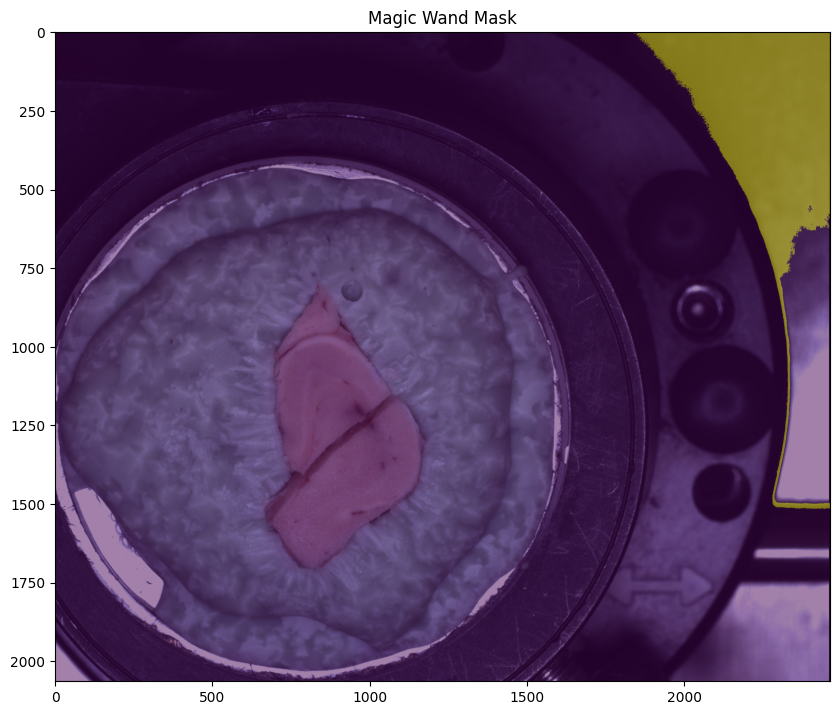

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
sid = 23
slab_path = blocks_path / f"{donor}.CX.{sid:02d}"
print(slab_path)
cryostat_tr_seed = (2360, 200)
cryostat_bl_seed = (80, 2000)
# Pick a seed inside the metallic top-right region by inspecting one image.
result = register_translations_via_magic_wand(
    sorted(list(slab_path.glob("*.tif")))[:2],
    seed_xy=cryostat_tr_seed,     # x, y in pixels
    tolerance=30,          # bump this if the metallic texture is hetero
    upsample_factor=10,    # 0.1-pixel precision
    return_aligned=True,
)
mask = result["mask"]              # uint8 0/255, useful for QC overlay
shifts = result["shifts"]          # {path: (dy, dx)} to apply to moving
aligned = result["aligned"]        # {path: shifted 3-channel BGR uint8}

# Plot the mask
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.imshow(mask, alpha=0.5)
plt.title("Magic Wand Mask")
plt.show()

registered_path = slab_path / f"registered_{int(normalized_resolution)}um_per_px"
registered_path.mkdir(exist_ok=True)
for path, img in aligned.items():
    img_normalized = cv2.resize(
        img,
        dsize=None,
        fx=scale_factor,
        fy=scale_factor,
        interpolation=cv2.INTER_CUBIC,
    )
    filename = Path(path).name
    specimen_name = filename.split("_")[0]
    out_path = registered_path / f"{specimen_name}.png"
    cv2.imwrite(out_path.as_posix(), img_normalized)

## Segment and crop

1. Pick bounding box corners with cv2 mouse annotation
1. Segment with Segment Anything Model
1. Crop to bounding box

In [3]:
slab_path = blocks_path / f"{donor}.CX.{sid:02d}"
registered_path = slab_path / f"registered_{int(normalized_resolution)}um_per_px"
presegment_path = registered_path
segmented_path = slab_path / "processed"
segmented_path.mkdir(exist_ok=True)

img_paths = list(presegment_path.glob("*.png"))
unique_blocks = set(".".join(p.stem.split(".")[:6]) for p in img_paths)

for block in unique_blocks:
    block_img_paths = [p for p in img_paths if p.stem.startswith(block)]
    segment_slab_registered(
        block_img_paths,
        predictor,
        output_dir=segmented_path,
        show_qc=True,
    )



Annotating tissue bbox on H24.30.005.CX.23.01.03.02...
Processing H24.30.005.CX.23.01.03.02...


/home/mike/workspace/hmba-stx-registration/src/hmba_stx_registration/block_processing/block_segmentation.py:533: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Processing H24.30.005.CX.23.01...
Processing H24.30.005.CX.23.01.01.02...
Processing H24.30.005.CX.23.01.07.02...
Processing H24.30.005.CX.23.01.05.02...
Annotating tissue bbox on H24.30.005.CX.23.02.05.02...
Processing H24.30.005.CX.23.02.05.02...
Processing H24.30.005.CX.23.02.07.01...
Processing H24.30.005.CX.23.02.01.02...
Processing H24.30.005.CX.23.02.03.02...
